In [ ]:
!pip install torchsummary

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Transform: Convert to tensor and normalize, plus a simple augmentation
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

print(f"Training samples: {len(trainset)} | Testing samples: {len(testset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 21.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 538kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 6.00MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]

Training samples: 60000 | Testing samples: 10000


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Input: 1x28x28 (MNIST grayscale)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 16x14x14

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 32x7x7

        self.fc = nn.Linear(32 * 7 * 7, 10) # 10 classes for MNIST

    def forward(self, x):
        # We save intermediate steps as attributes to easily visualize them later
        self.out_conv1 = self.conv1(x)
        self.out_relu1 = self.relu1(self.out_conv1)
        self.out_pool1 = self.pool1(self.out_relu1)

        self.out_conv2 = self.conv2(self.out_pool1)
        self.out_relu2 = self.relu2(self.out_conv2)
        self.out_pool2 = self.pool2(self.out_relu2)

        out = self.out_pool2.view(-1, 32 * 7 * 7) # Flatten
        out = self.fc(out)
        return out

model = SimpleCNN().to(device)
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
              ReLU-2           [-1, 16, 28, 28]               0
         MaxPool2d-3           [-1, 16, 14, 14]               0
            Conv2d-4           [-1, 32, 14, 14]           4,640
              ReLU-5           [-1, 32, 14, 14]               0
         MaxPool2d-6             [-1, 32, 7, 7]               0
            Linear-7                   [-1, 10]          15,690
Total params: 20,490
Trainable params: 20,490
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.32
Params size (MB): 0.08
Estimated Total Size (MB): 0.40
----------------------------------------------------------------


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 3 # Keeping it short for the assignment

train_losses, train_accuracies = [], []

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

Epoch 1/3 | Loss: 0.3593 | Accuracy: 88.73%
Epoch 2/3 | Loss: 0.1596 | Accuracy: 94.76%
Epoch 3/3 | Loss: 0.1255 | Accuracy: 95.97%


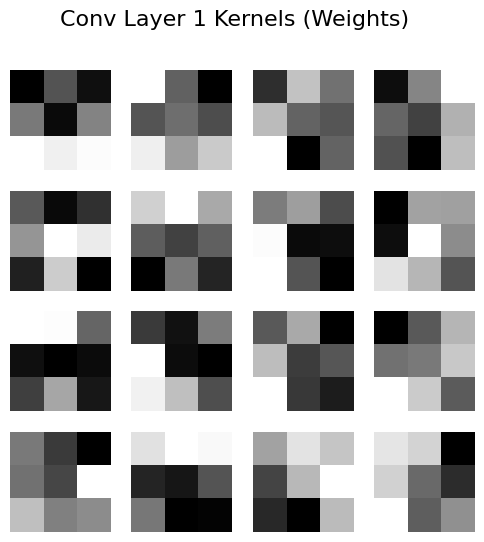


--- Feature Maps ---


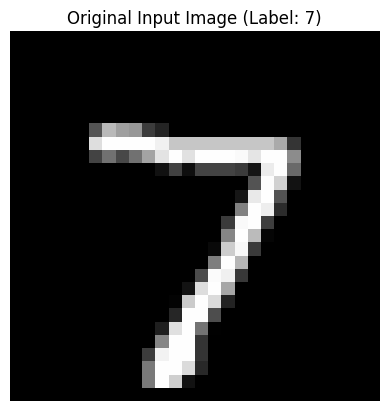

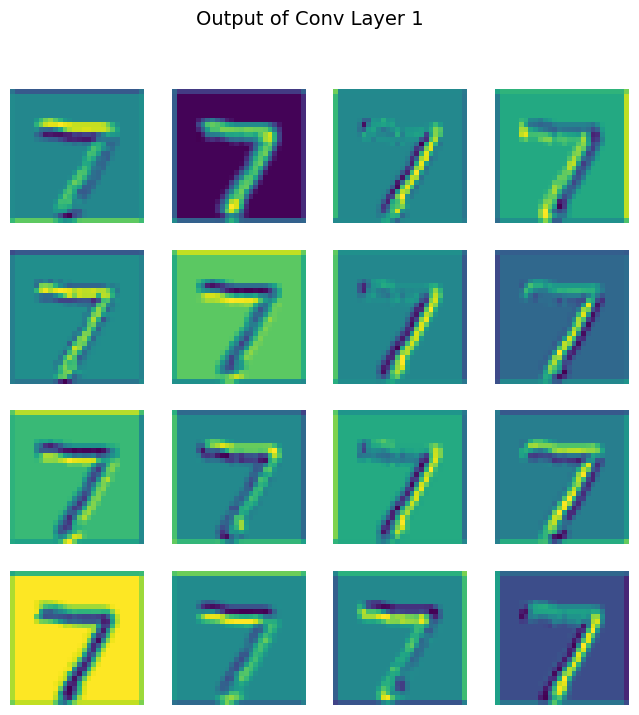

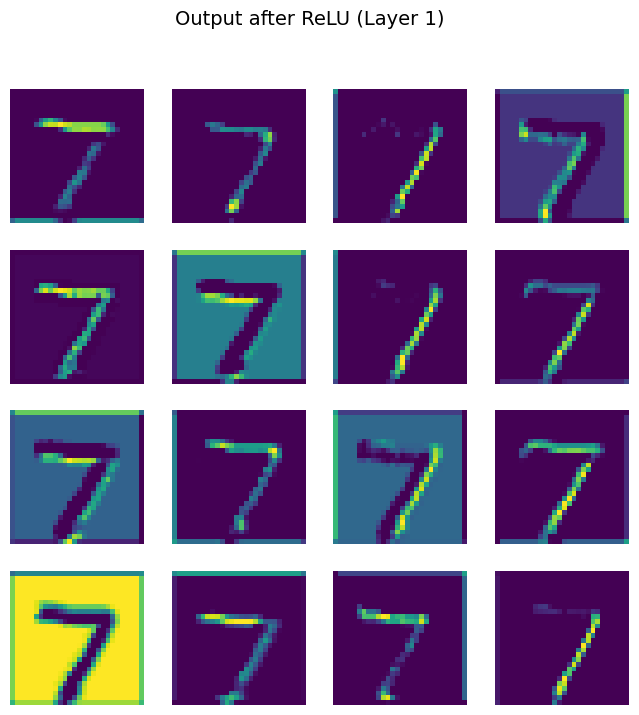

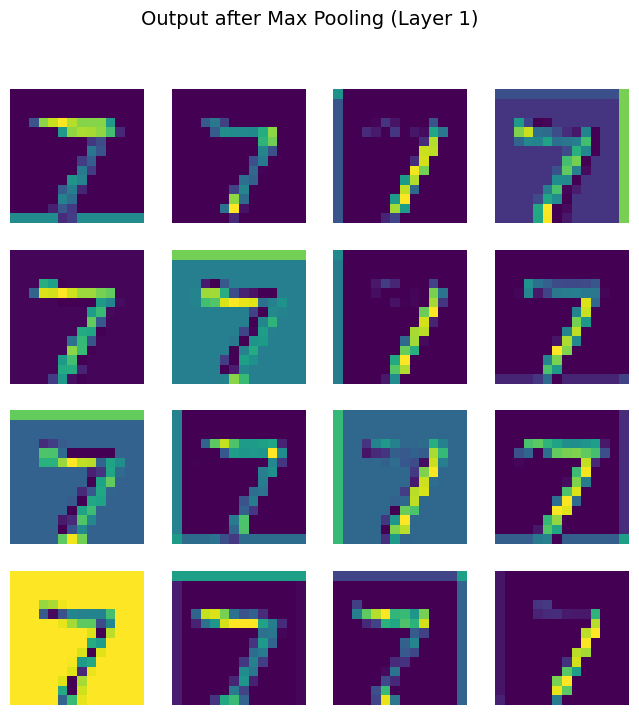

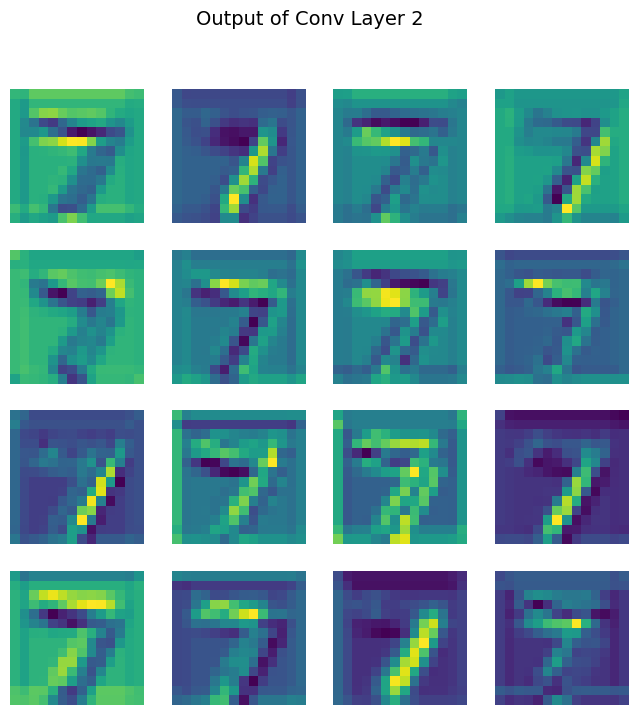

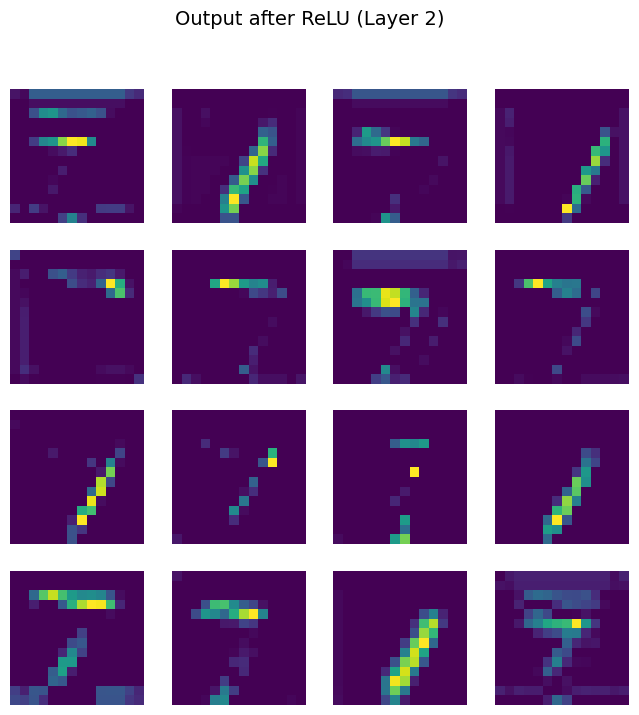

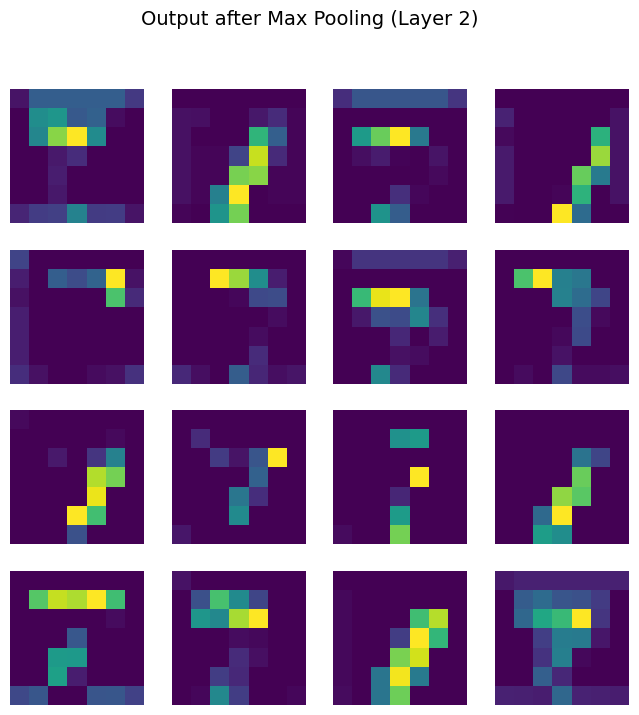

In [ ]:
model.eval()

# 1. Visualize Kernels of Conv Layer 1
kernels = model.conv1.weight.detach().cpu().numpy()
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
fig.suptitle('Conv Layer 1 Kernels (Weights)', fontsize=16)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(kernels[i][0], cmap='gray')
    ax.axis('off')
plt.show()

# 2. Visualize Feature Maps
dataiter = iter(testloader)
images, labels = next(dataiter)
sample_img = images[0].unsqueeze(0).to(device) # Take first image and add batch dimension

# Forward pass to generate internal states
_ = model(sample_img)

def plot_feature_maps(feature_map_tensor, title):
    fmaps = feature_map_tensor.detach().cpu().numpy()[0]
    num_maps = min(16, fmaps.shape[0]) # Show max 16 maps
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle(title, fontsize=14)
    for i, ax in enumerate(axes.flatten()):
        if i < num_maps:
            ax.imshow(fmaps[i], cmap='viridis')
        ax.axis('off')
    plt.show()

print("\n--- Feature Maps ---")
plt.imshow(sample_img.cpu().squeeze(), cmap='gray')
plt.title(f"Original Input Image (Label: {labels[0]})")
plt.axis('off')
plt.show()

plot_feature_maps(model.out_conv1, "Output of Conv Layer 1")
plot_feature_maps(model.out_relu1, "Output after ReLU (Layer 1)")
plot_feature_maps(model.out_pool1, "Output after Max Pooling (Layer 1)")
plot_feature_maps(model.out_conv2, "Output of Conv Layer 2")
plot_feature_maps(model.out_relu2, "Output after ReLU (Layer 2)")
plot_feature_maps(model.out_pool2, "Output after Max Pooling (Layer 2)")

Test Accuracy: 96.48%



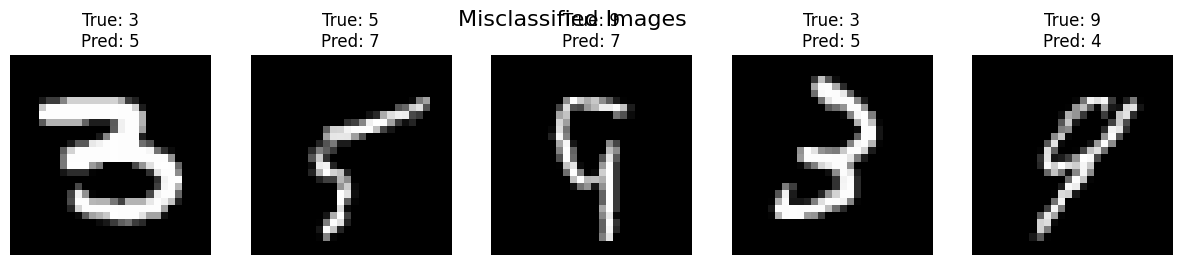

In [ ]:
model.eval()
correct, total = 0, 0
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Track misclassifications
        incorrect_mask = predicted != labels
        if incorrect_mask.any():
            for i in range(len(incorrect_mask)):
                if incorrect_mask[i] and len(misclassified_images) < 5:
                    misclassified_images.append(inputs[i].cpu())
                    misclassified_labels.append(labels[i].item())
                    misclassified_preds.append(predicted[i].item())

print(f"Test Accuracy: {100. * correct / total:.2f}%\n")

# Plot misclassifications
fig, axes = plt.subplots(1, len(misclassified_images), figsize=(15, 3))
fig.suptitle("Misclassified Images", fontsize=16)
for i, ax in enumerate(axes):
    ax.imshow(misclassified_images[i].squeeze(), cmap='gray')
    ax.set_title(f"True: {misclassified_labels[i]}\nPred: {misclassified_preds[i]}")
    ax.axis('off')
plt.show()